
## Dataset: Breast Cancer Wisconsin (Diagnostic)
Mô tả
Notebook này thực hiện xây dựng và đánh giá mô hình Decision Tree trên bộ dữ liệu **Breast Cancer Wisconsin (Diagnostic)**. Nội dung bao gồm:
1.  **Chuẩn bị dữ liệu:** Tải dữ liệu và tiền xử lý.
2.  **Phân tích tỷ lệ chia (Split Ratio):** Đánh giá hiệu suất trên các tỷ lệ train/test khác nhau ($40/60$, $60/40$, $80/20$, $90/10$).
3.  **Phân tích độ sâu cây (Max Depth):** Khảo sát ảnh hưởng của độ sâu cây đến độ chính xác trên tập dữ liệu $80/20$.

Đang đọc dữ liệu từ: ../data/custom_dataset/breast_cancer.csv
---> Cột Label được chọn: 'Diagnosis'
Label đang là dạng chữ, tiến hành mã hóa sang số...
Đang loại bỏ các cột không cần thiết: ['ID']

Kích thước X: (569, 30)
Kích thước y: (569,)

>>> ĐANG HUẤN LUYỆN MÔ HÌNH...
Độ chính xác trên tập Test: 94.74%

>>> ĐANG TẠO HÌNH ẢNH CÂY QUYẾT ĐỊNH (GRAPHVIZ)...
✅ Đã lưu ảnh cây vào: ..\outputs\Breast_Cancer_Tree_Graphviz.png


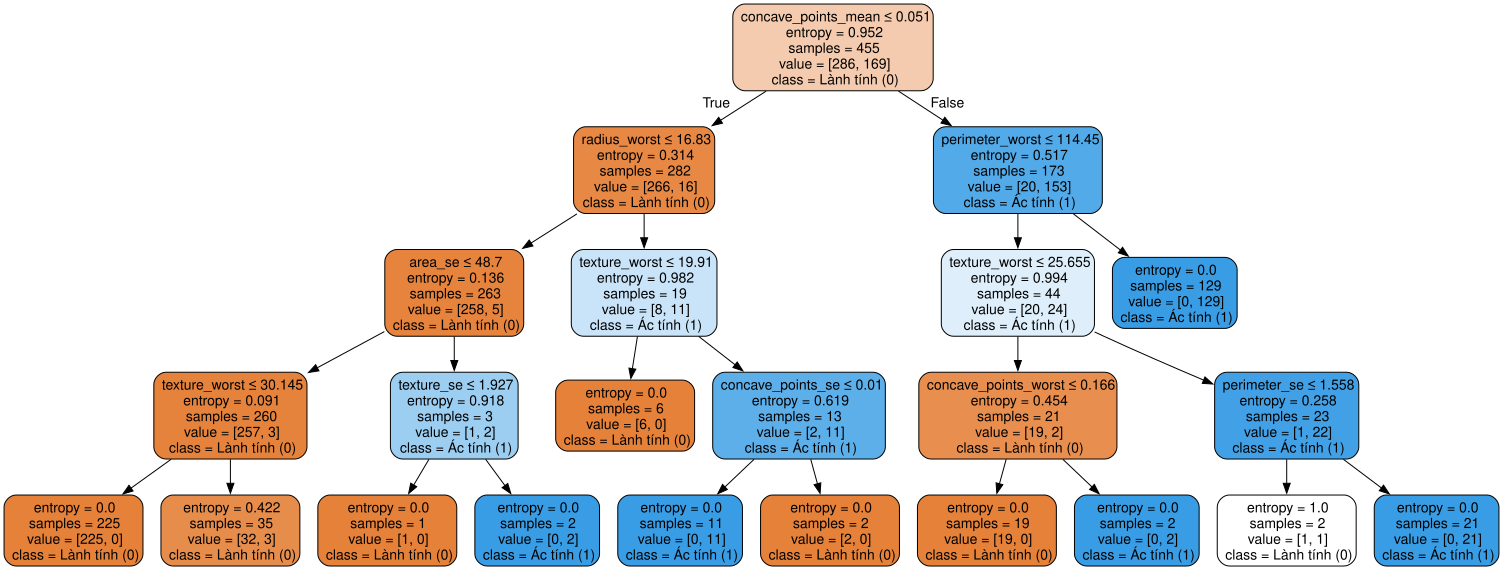

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz  # <--- Thư viện quan trọng
import os
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from IPython.display import display

# =========================================================
# 1. TẢI VÀ XỬ LÝ DỮ LIỆU (Code cũ của bạn)
# =========================================================
csv_path = '../data/custom_dataset/breast_cancer.csv'

if os.path.exists(csv_path):
    print(f"Đang đọc dữ liệu từ: {csv_path}")
    df = pd.read_csv(csv_path)
else:
    print("⚠️ Không tìm thấy file CSV, dùng dataset mẫu từ sklearn.")
    from sklearn.datasets import load_breast_cancer
    data = load_breast_cancer()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target

# --- Xử lý cột Label ---
possible_targets = ['target', 'diagnosis', 'class', 'label', 'Outcome']
target_col = None
for col in df.columns:
    if col.lower() in possible_targets:
        target_col = col
        break

if target_col is None:
    target_col = df.columns[-1] 
    print(f"CẢNH BÁO: Đang thử dùng cột cuối cùng làm label: '{target_col}'")

print(f"---> Cột Label được chọn: '{target_col}'")

# --- Mã hóa Label (M->1, B->0) ---
if df[target_col].dtype == 'object':
    print("Label đang là dạng chữ, tiến hành mã hóa sang số...")
    df[target_col] = df[target_col].map({'M': 1, 'B': 0, 'malignant': 1, 'benign': 0})
    df = df.dropna(subset=[target_col])

# --- Tách X và y ---
X = df.drop(columns=[target_col])
# Loại bỏ cột rác (id, unnamed...)
cols_to_drop = [c for c in X.columns if 'id' in c.lower() or 'unnamed' in c.lower()]
if cols_to_drop:
    print(f"Đang loại bỏ các cột không cần thiết: {cols_to_drop}")
    X = X.drop(columns=cols_to_drop)

y = df[target_col]

# Cập nhật tên lớp (cho đẹp khi vẽ)
# Nếu là bài toán ung thư vú: 0 = Benign (Lành tính), 1 = Malignant (Ác tính)
class_names = ['Lành tính (0)', 'Ác tính (1)'] if len(np.unique(y)) == 2 else [str(c) for c in np.unique(y)]
feature_names = X.columns.tolist()

print(f"\nKích thước X: {X.shape}")
print(f"Kích thước y: {y.shape}")

# =========================================================
# 2. HUẤN LUYỆN MÔ HÌNH (THÊM MỚI)
# =========================================================
print("\n>>> ĐANG HUẤN LUYỆN MÔ HÌNH...")

# Chia dữ liệu 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tạo mô hình (Giới hạn độ sâu = 4 để cây không quá to, dễ nhìn)
clf = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# Đánh giá sơ bộ
y_pred = clf.predict(X_test)
print(f"Độ chính xác trên tập Test: {accuracy_score(y_test, y_pred):.2%}")

# =========================================================
# 3. VẼ CÂY BẰNG GRAPHVIZ (THAY THẾ PLOT_TREE)
# =========================================================
print("\n>>> ĐANG TẠO HÌNH ẢNH CÂY QUYẾT ĐỊNH (GRAPHVIZ)...")

# Thiết lập thư mục lưu ảnh
output_dir = '../outputs'
if not os.path.exists(output_dir):
    try:
        os.makedirs(output_dir)
    except:
        output_dir = 'outputs' # Fallback nếu chạy ở thư mục gốc
        if not os.path.exists(output_dir): os.makedirs(output_dir)

# Tạo dữ liệu DOT
dot_data = export_graphviz(clf, 
                           out_file=None, 
                           feature_names=feature_names,  
                           class_names=class_names,  
                           filled=True, 
                           rounded=True,  
                           special_characters=True)

# Tạo graph từ DOT
graph = graphviz.Source(dot_data)

# --- TÙY CHỌN XUẤT FILE ---
# Bạn có thể chọn 'png' hoặc 'pdf' (pdf zoom nét hơn)
graph.format = 'png' 
filename = "Breast_Cancer_Tree_Graphviz"

try:
    output_path = graph.render(filename=filename, directory=output_dir, view=False, cleanup=True)
    print(f"✅ Đã lưu ảnh cây vào: {output_path}")
    
    # Hiển thị lên màn hình Notebook
    display(graph)
except Exception as e:
    print(f"❌ Lỗi khi lưu ảnh (có thể do chưa cài Graphviz system path): {e}")

## 1. Phân tích hiệu suất theo tỷ lệ chia (Train/Test Split)

Trong phần này, chúng ta sẽ chia dữ liệu theo 4 tỷ lệ: **40/60, 60/40, 80/20, và 90/10**.
Với mỗi tỷ lệ, thực hiện:
* Chia dữ liệu có phân tầng (Stratified shuffle split).
* Huấn luyện mô hình Decision Tree (sử dụng *Entropy*).
* Đánh giá bằng **Confusion Matrix** và **Classification Report**.
* Trực quan hóa cây quyết định.


TỶ LỆ TRAIN: 40% - TEST: 60%
Confusion Matrix:
[[206   9]
 [ 21 106]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       215
           1       0.92      0.83      0.88       127

    accuracy                           0.91       342
   macro avg       0.91      0.90      0.90       342
weighted avg       0.91      0.91      0.91       342

-> Hình minh họa cây quyết định (Tỷ lệ 40%):


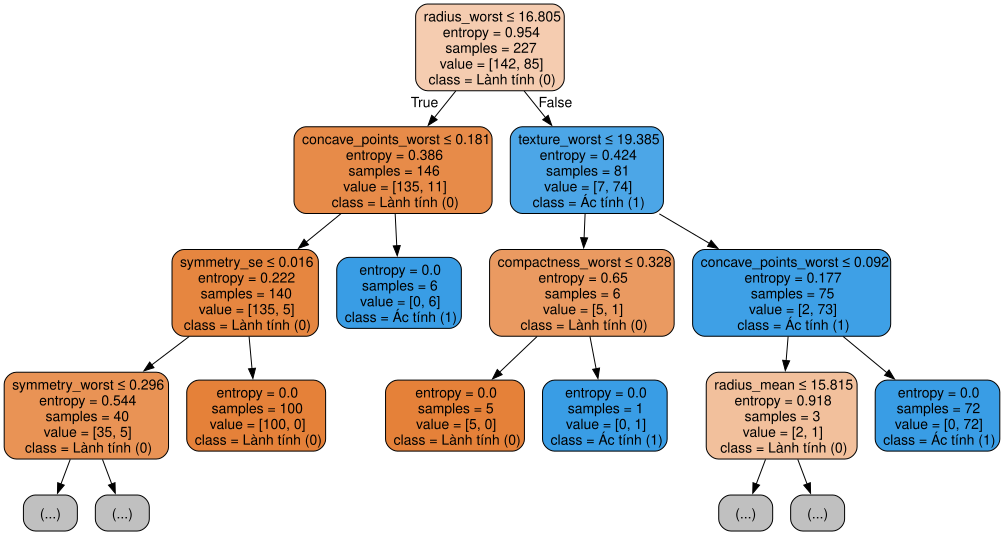


TỶ LỆ TRAIN: 60% - TEST: 40%
Confusion Matrix:
[[137   6]
 [  8  77]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       143
           1       0.93      0.91      0.92        85

    accuracy                           0.94       228
   macro avg       0.94      0.93      0.93       228
weighted avg       0.94      0.94      0.94       228

-> Hình minh họa cây quyết định (Tỷ lệ 60%):


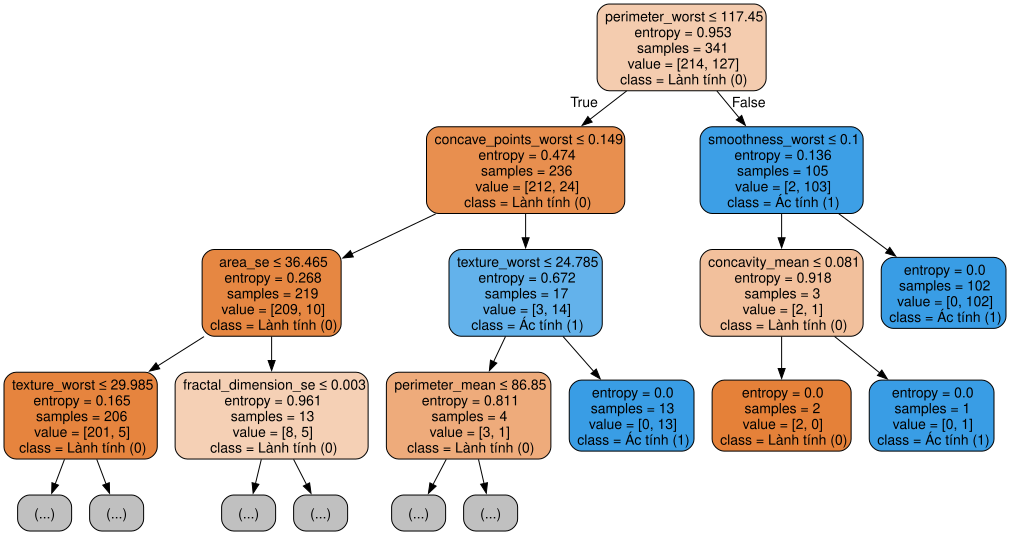


TỶ LỆ TRAIN: 80% - TEST: 20%
Confusion Matrix:
[[71  1]
 [ 4 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

-> Hình minh họa cây quyết định (Tỷ lệ 80%):


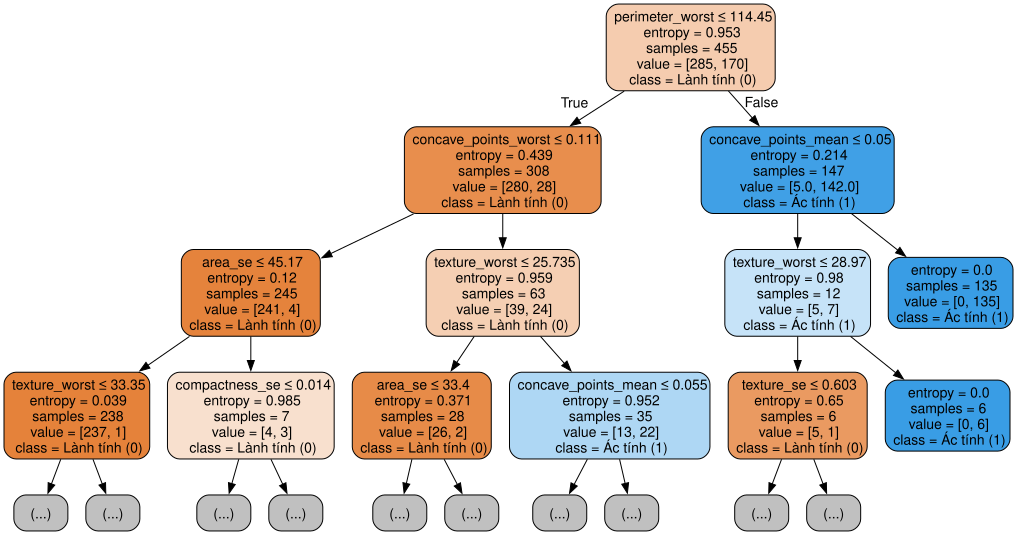


TỶ LỆ TRAIN: 90% - TEST: 10%
Confusion Matrix:
[[35  1]
 [ 2 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        36
           1       0.95      0.90      0.93        21

    accuracy                           0.95        57
   macro avg       0.95      0.94      0.94        57
weighted avg       0.95      0.95      0.95        57

-> Hình minh họa cây quyết định (Tỷ lệ 90%):


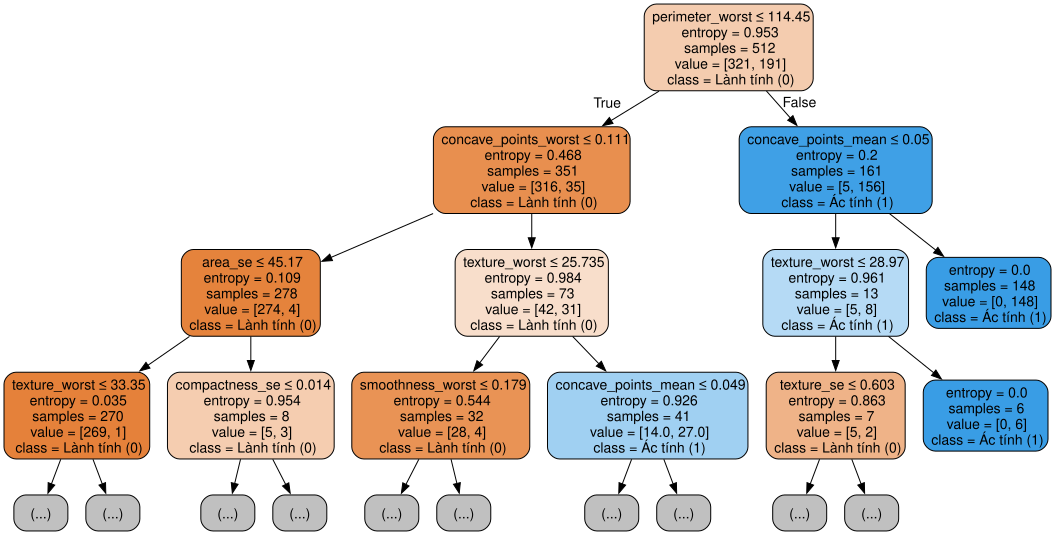


ĐÃ HOÀN TẤT KHẢO SÁT!


In [9]:
import matplotlib.pyplot as plt

import pandas as pd

import graphviz

from sklearn.tree import DecisionTreeClassifier, export_graphviz

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import train_test_split

from IPython.display import display



# =========================================================

# KHẢO SÁT TỶ LỆ TRAIN/TEST (CHỈ HIỂN THỊ, KHÔNG LƯU FILE)

# =========================================================



# Danh sách các tỷ lệ train

ratios = [0.4, 0.6, 0.8, 0.9]



for ratio in ratios:

    test_size = 1.0 - ratio

    print(f"\n{'='*30}")

    print(f"TỶ LỆ TRAIN: {int(ratio*100)}% - TEST: {int(test_size*100 + 0.1)}%")

    print(f"{'='*30}")

   

    # 1. Chia dữ liệu

    X_train, X_test, y_train, y_test = train_test_split(

        X, y, test_size=test_size, stratify=y, shuffle=True, random_state=42

    )

   

    # 2. Huấn luyện mô hình (Entropy)

    clf = DecisionTreeClassifier(criterion='entropy', random_state=42)

    clf.fit(X_train, y_train)

   

    # 3. Dự đoán & Báo cáo kết quả

    y_pred = clf.predict(X_test)

   

    print("Confusion Matrix:")

    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")

    print(classification_report(y_test, y_pred))

   

    # 4. Vẽ cây bằng Graphviz (Hiển thị trực tiếp)

    print(f"-> Hình minh họa cây quyết định (Tỷ lệ {int(ratio*100)}%):")

   

    dot_data = export_graphviz(clf,

                               out_file=None,

                               feature_names=feature_names,

                               class_names=class_names,

                               filled=True,

                               rounded=True,

                               special_characters=True,

                               max_depth=3) # Giới hạn hiển thị 3 tầng

   

    # Tạo đối tượng graph và hiển thị ngay lập tức

    graph = graphviz.Source(dot_data)

    display(graph)



print("\n" + "="*50)

print("ĐÃ HOÀN TẤT KHẢO SÁT!")

## 2. Khảo sát ảnh hưởng của độ sâu cây (Max Depth)

Phần này tập trung vào tỷ lệ chia **80/20**. Chúng ta sẽ giới hạn độ sâu của cây (`max_depth`) với các giá trị: **[2, 3, 4, 5, 6, 7, None]** để xem xét sự cân bằng giữa *Underfitting* và *Overfitting*.

Kết quả sẽ được tổng hợp thành bảng và biểu đồ đường.

>>> Ảnh kết quả sẽ được lưu vào: d:\DecisionTree\outputs


ĐỘ SÂU: 2  |  ĐỘ CHÍNH XÁC: 0.8860
-> Cây vừa phải: Lưu dạng PNG (Ảnh).
✅ Đã lưu file: BreastCancer_Depth_2.png


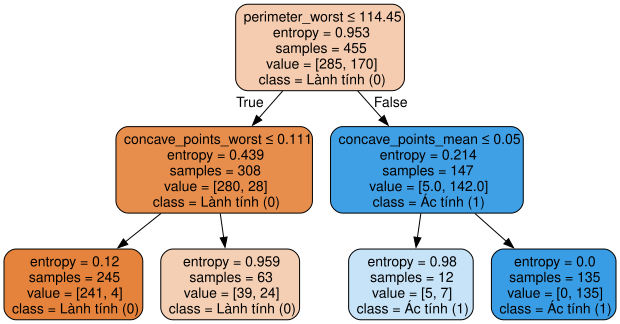


ĐỘ SÂU: 3  |  ĐỘ CHÍNH XÁC: 0.9386
-> Cây vừa phải: Lưu dạng PNG (Ảnh).
✅ Đã lưu file: BreastCancer_Depth_3.png


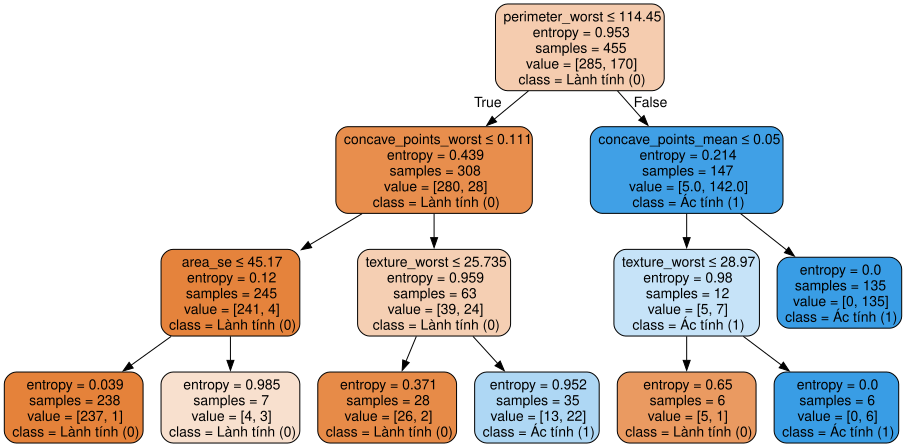


ĐỘ SÂU: 4  |  ĐỘ CHÍNH XÁC: 0.9298
-> Cây vừa phải: Lưu dạng PNG (Ảnh).
✅ Đã lưu file: BreastCancer_Depth_4.png


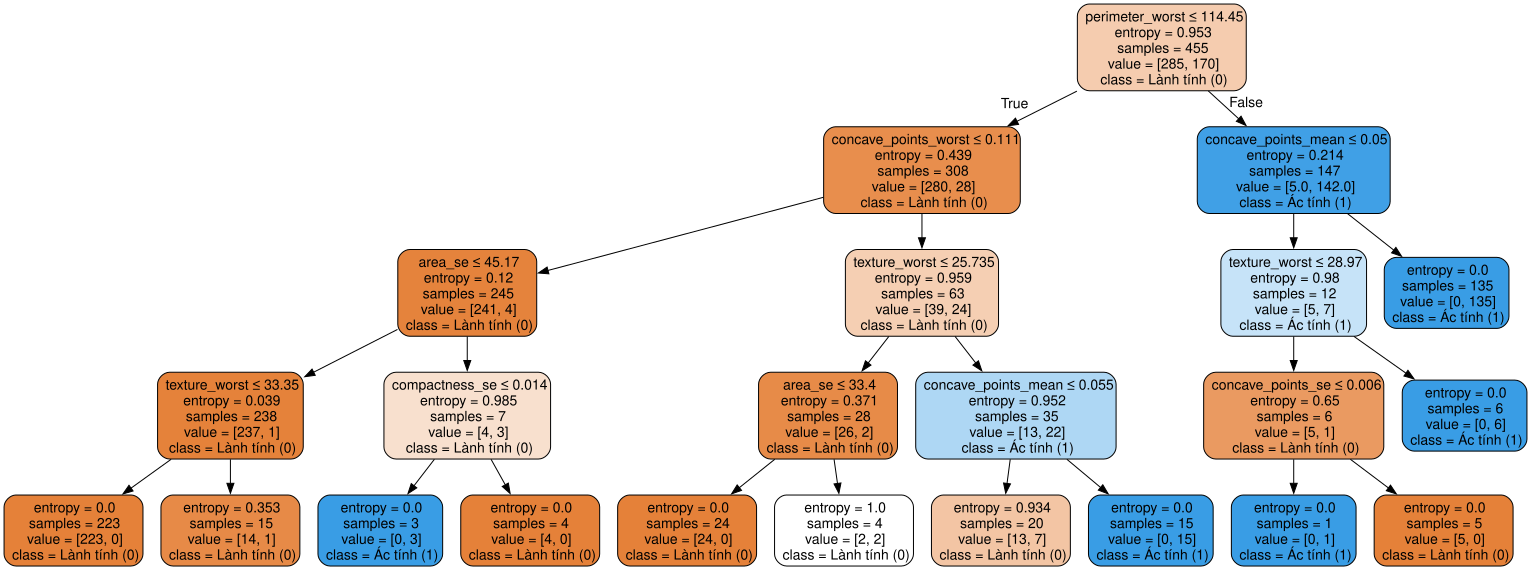


ĐỘ SÂU: 5  |  ĐỘ CHÍNH XÁC: 0.9561
-> Cây vừa phải: Lưu dạng PNG (Ảnh).
✅ Đã lưu file: BreastCancer_Depth_5.png


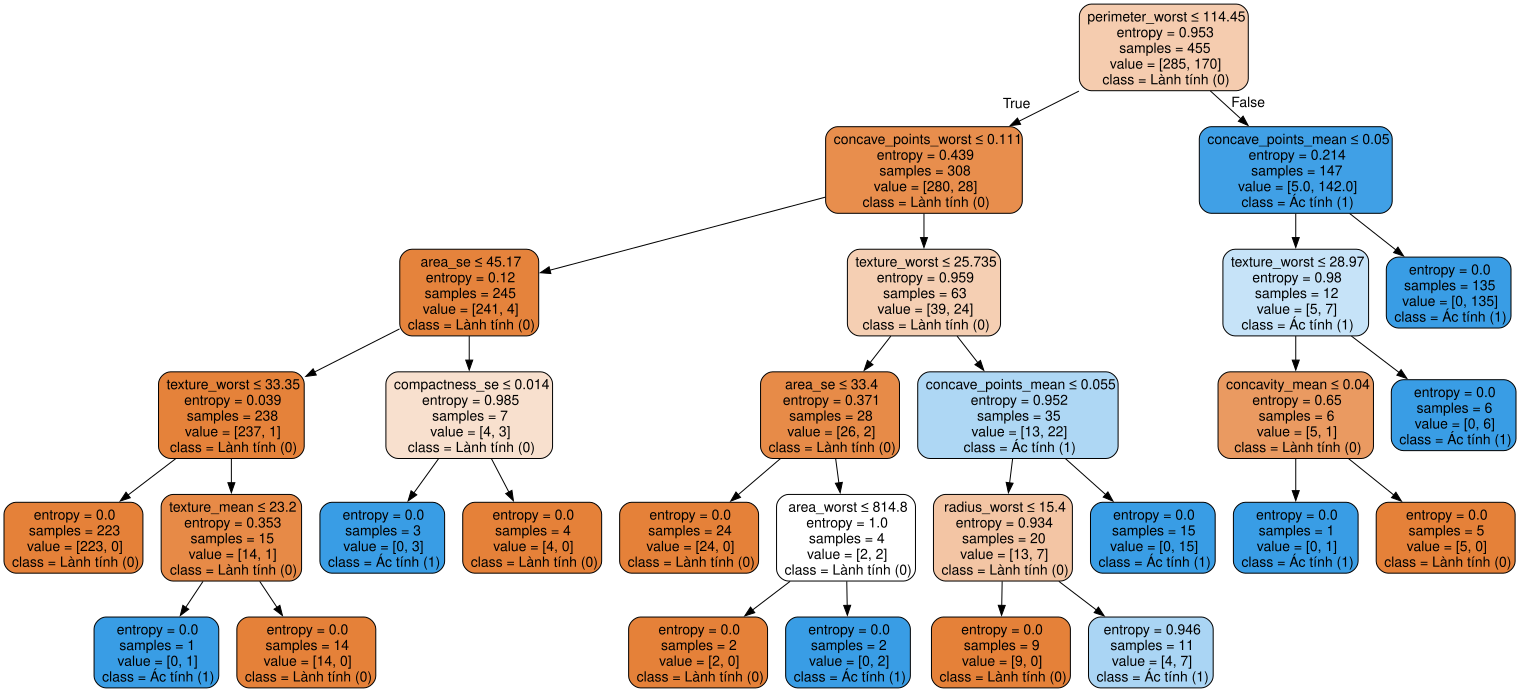


ĐỘ SÂU: 6  |  ĐỘ CHÍNH XÁC: 0.9298
-> Cây vừa phải: Lưu dạng PNG (Ảnh).
✅ Đã lưu file: BreastCancer_Depth_6.png


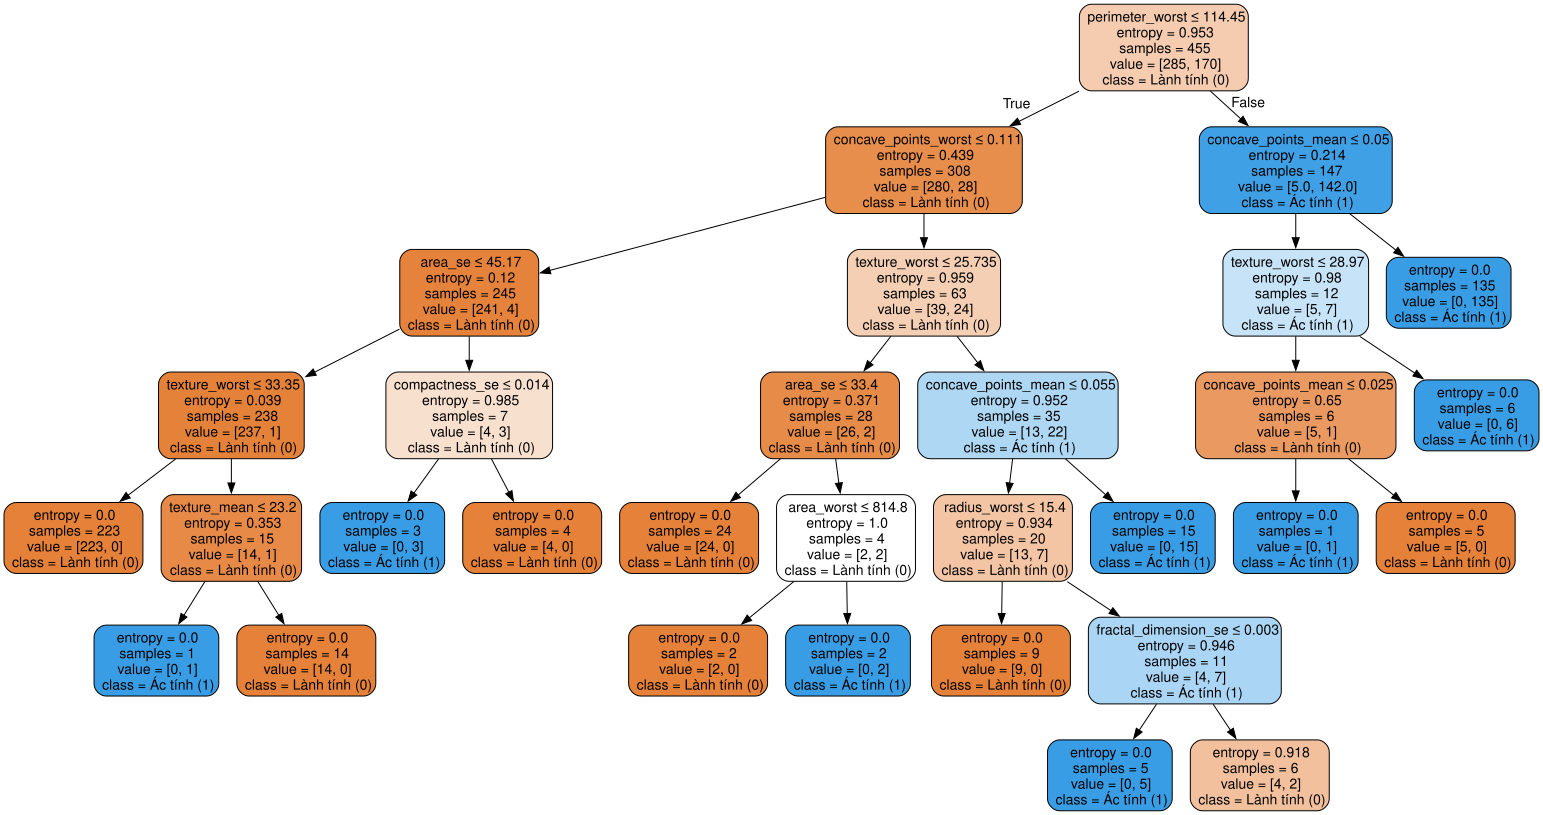


ĐỘ SÂU: 7  |  ĐỘ CHÍNH XÁC: 0.9561
-> Cây vừa phải: Lưu dạng PNG (Ảnh).
✅ Đã lưu file: BreastCancer_Depth_7.png


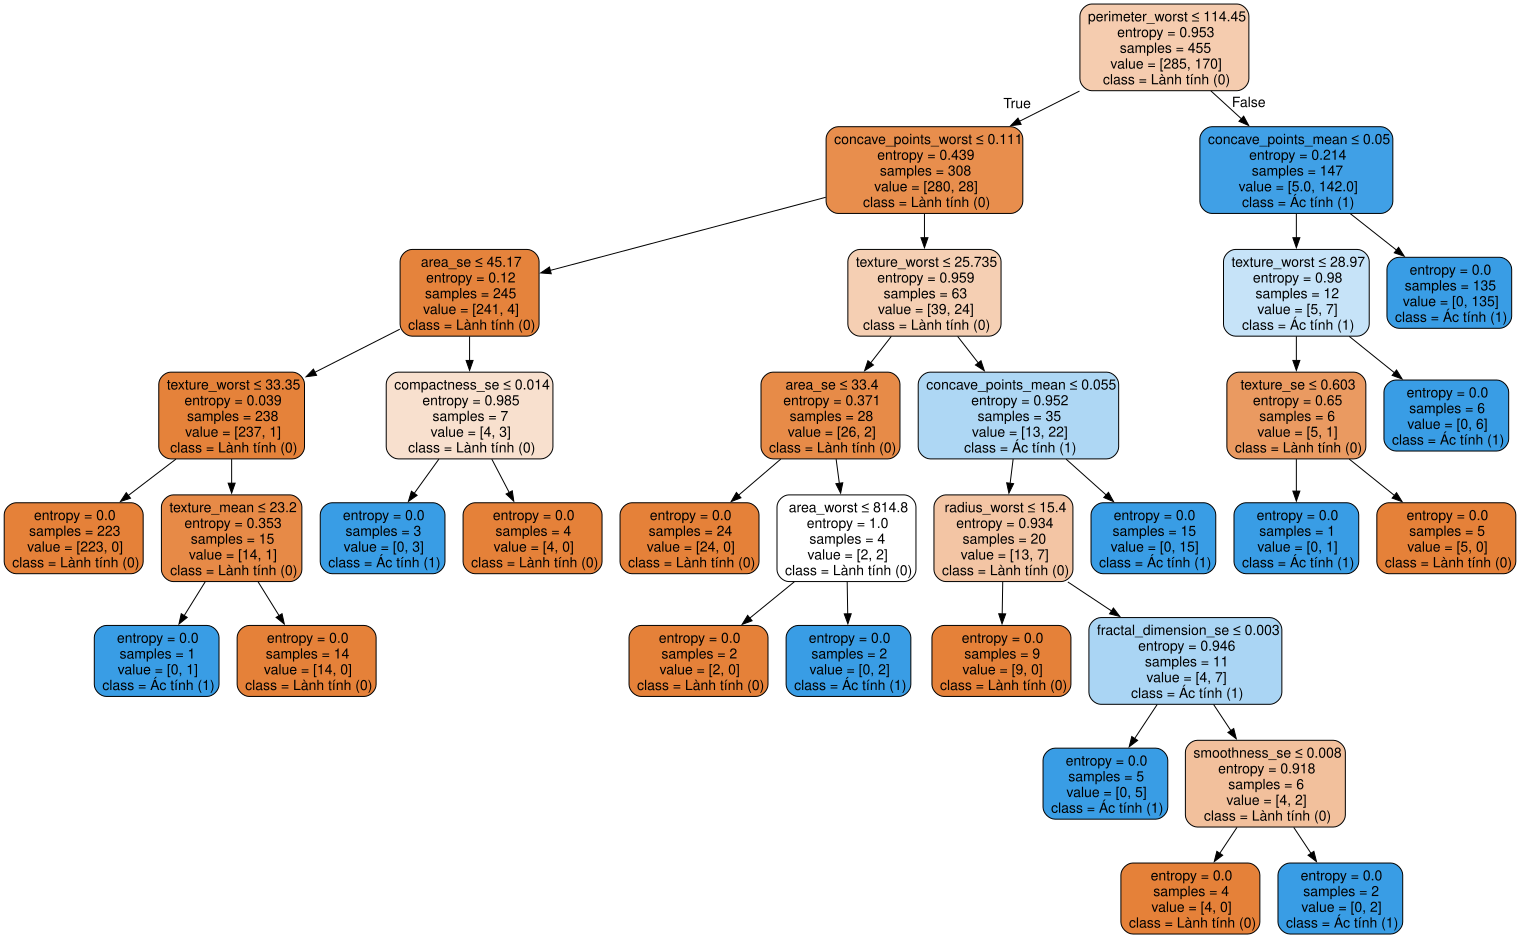


ĐỘ SÂU: None (Max)  |  ĐỘ CHÍNH XÁC: 0.9561
-> Cây khổng lồ: Đã chuyển sang chế độ lưu PDF (Vector).
✅ Đã lưu file: BreastCancer_Depth_None_Max.pdf
⚠️ (File PDF đã được lưu. Hãy mở folder để xem chi tiết)


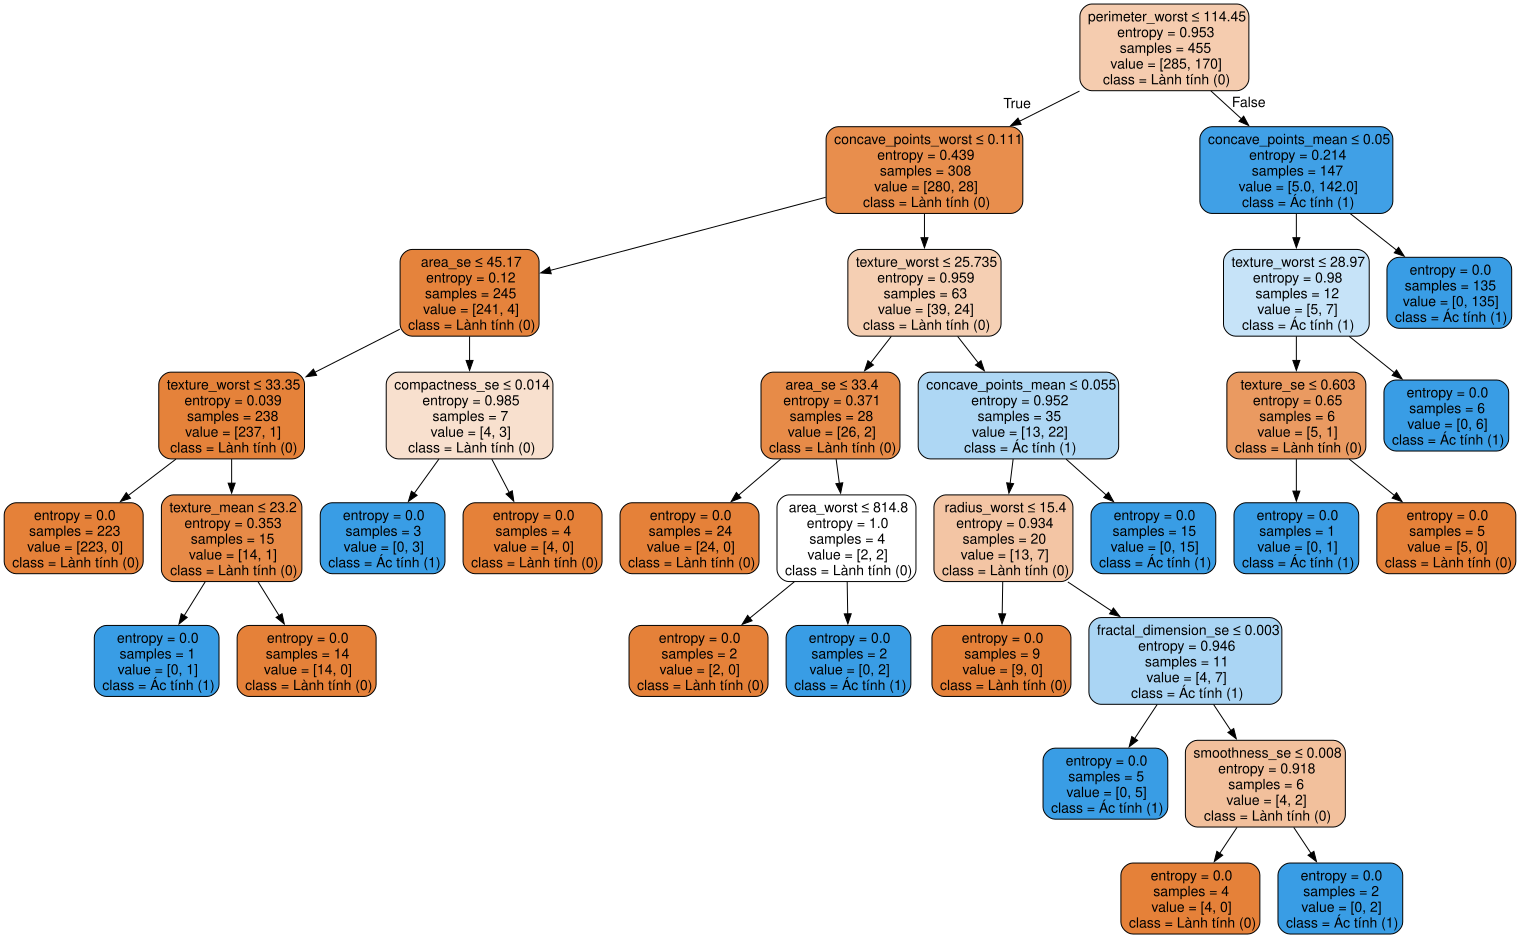

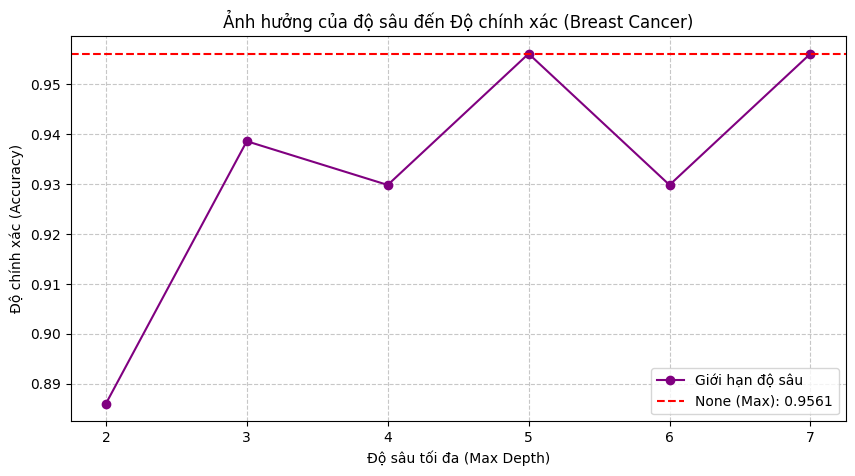


>>> BẢNG TỔNG HỢP KẾT QUẢ:


,Max Depth,Accuracy
0,2,0.885965
1,3,0.938596
2,4,0.929825
3,5,0.956140
4,6,0.929825
5,7,0.956140
6,None (Max),0.956140


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import graphviz
import os
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from IPython.display import display

# =========================================================
# KHẢO SÁT ĐỘ SÂU (ƯU TIÊN PNG, CHỈ DÙNG PDF KHI CẦN)
# =========================================================

# 1. Thiết lập thư mục lưu
output_dir = '../outputs'
if not os.path.exists(output_dir):
    try:
        os.makedirs(output_dir)
    except:
        output_dir = 'outputs'
        if not os.path.exists(output_dir): os.makedirs(output_dir)

print(f">>> Ảnh kết quả sẽ được lưu vào: {os.path.abspath(output_dir)}\n")

# 2. Cố định tập train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Danh sách độ sâu
depths = [2, 3, 4, 5, 6, 7, None]
results = []

for depth in depths:
    # A. HUẤN LUYỆN
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    
    # B. TÍNH ĐỘ CHÍNH XÁC
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    depth_label = str(depth) if depth is not None else "None (Max)"
    results.append((depth_label, acc))
    
    # C. VẼ VÀ LƯU CÂY
    print(f"\n{'='*60}")
    print(f"ĐỘ SÂU: {depth_label}  |  ĐỘ CHÍNH XÁC: {acc:.4f}")
    
    # Tạo dữ liệu vẽ
    dot_data = export_graphviz(clf, 
                               out_file=None, 
                               feature_names=feature_names, 
                               class_names=class_names, 
                               filled=True, 
                               rounded=True, 
                               special_characters=True,
                               max_depth=depth) # Vẽ full độ sâu hiện tại
    
    graph = graphviz.Source(dot_data)
    
    # Đặt tên file sạch sẽ
    clean_label = depth_label.replace(' ', '_').replace('(', '').replace(')', '')
    filename = f"BreastCancer_Depth_{clean_label}"
    
    # --- LOGIC QUYẾT ĐỊNH ĐỊNH DẠNG FILE ---
    if depth is None:
        # Cây MAX -> Quá to -> Lưu PDF
        graph.format = 'pdf'
        print("-> Cây khổng lồ: Đã chuyển sang chế độ lưu PDF (Vector).")
        ext = ".pdf"
    else:
        # Cây nhỏ (2-7) -> Vừa phải -> Lưu PNG (Ảnh)
        graph.format = 'png'
        print("-> Cây vừa phải: Lưu dạng PNG (Ảnh).")
        ext = ".png"
    
    try:
        # Lưu xuống máy
        path = graph.render(filename=filename, directory=output_dir, view=False, cleanup=True)
        print(f"✅ Đã lưu file: {os.path.basename(path)}")
        
        # Hiển thị
        if depth is None:
            print("⚠️ (File PDF đã được lưu. Hãy mở folder để xem chi tiết)")
            display(graph)
        else:
            display(graph)
            
    except Exception as e:
        print(f"❌ Lỗi lưu ảnh: {e}")

# =========================================================
# TỔNG HỢP KẾT QUẢ
# =========================================================

# Vẽ biểu đồ đường
df_res = pd.DataFrame(results, columns=["Max Depth", "Accuracy"])
plt.figure(figsize=(10, 5))

# Lọc bỏ dòng None để vẽ biểu đồ đường
df_plot = df_res[df_res["Max Depth"] != "None (Max)"]

plt.plot(df_plot["Max Depth"].astype(int), df_plot["Accuracy"], marker='o', color='purple', linestyle='-', label='Giới hạn độ sâu')

# Vẽ đường tham chiếu cho Max Depth (None)
acc_none = df_res[df_res["Max Depth"] == "None (Max)"]["Accuracy"].values[0]
plt.axhline(y=acc_none, color='red', linestyle='--', label=f'None (Max): {acc_none:.4f}')

plt.title("Ảnh hưởng của độ sâu đến Độ chính xác (Breast Cancer)")
plt.xlabel("Độ sâu tối đa (Max Depth)")
plt.ylabel("Độ chính xác (Accuracy)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# In bảng kết quả
print("\n>>> BẢNG TỔNG HỢP KẾT QUẢ:")
display(df_res)